In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from scipy.interpolate import make_interp_spline

In [ ]:
data = pd.read_csv('/content/RFLFSODataFull.csv')

In [ ]:
data['SYNOPCode'].value_counts()

,count
SYNOPCode,
0,56964
6,25018
5,6605
8,1716
4,466
7,419
3,191


* '0' = clear
* '6' = rain
* '5' = drizzle
* '8' = showers
* '4' = fog
* '7' = snow
* '3' = dust storm

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FSO_Att                91379 non-null  float64
 1   RFL_Att                91379 non-null  float64
 2   AbsoluteHumidity       91379 non-null  float64
 3   AbsoluteHumidityMax    91379 non-null  float64
 4   AbsoluteHumidityMin    91379 non-null  float64
 5   Distance               91379 non-null  float64
 6   Frequency              91379 non-null  int64  
 7   Particulate            91379 non-null  float64
 8   ParticulateMax         91379 non-null  float64
 9   ParticulateMin         91379 non-null  float64
 10  RainIntensity          91379 non-null  float64
 11  RainIntensityMax       91379 non-null  float64
 12  RainIntensityMin       91379 non-null  float64
 13  RelativeHumidity       91379 non-null  float64
 14  SYNOPCode              91379 non-null  int64  
 15  Te

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
FSO_Att,91379.0,6.769458e+00,3.903843e+00,7.883633e-01,3.473063e+00,6.336167e+00,8.664984e+00,3.245522e+01
RFL_Att,91379.0,1.161910e+01,3.438873e+00,2.714198e-02,1.082933e+01,1.185656e+01,1.284794e+01,4.689315e+01
AbsoluteHumidity,91379.0,9.553919e+00,5.858577e+00,1.141556e+00,4.958993e+00,6.870737e+00,1.404947e+01,2.479088e+01
AbsoluteHumidityMax,91379.0,1.003276e+01,6.162798e+00,1.238270e+00,5.205861e+00,7.205499e+00,1.478268e+01,2.640731e+01
AbsoluteHumidityMin,91379.0,9.076251e+00,5.575927e+00,1.049744e+00,4.709511e+00,6.524046e+00,1.337926e+01,2.426843e+01
Distance,91379.0,3.297930e+03,1.224306e+03,2.012000e+03,2.019432e+03,2.959864e+03,4.820890e+03,4.828000e+03
Frequency,91379.0,7.850005e+10,5.000027e+09,7.350000e+10,7.350000e+10,8.350000e+10,8.350000e+10,8.350000e+10
Particulate,91379.0,2.706598e+01,7.213402e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.694762e+01,1.621002e+03
ParticulateMax,91379.0,2.841712e+01,7.576190e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.777598e+01,1.753748e+03
ParticulateMin,91379.0,2.571709e+01,6.859524e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.603809e+01,1.500666e+03


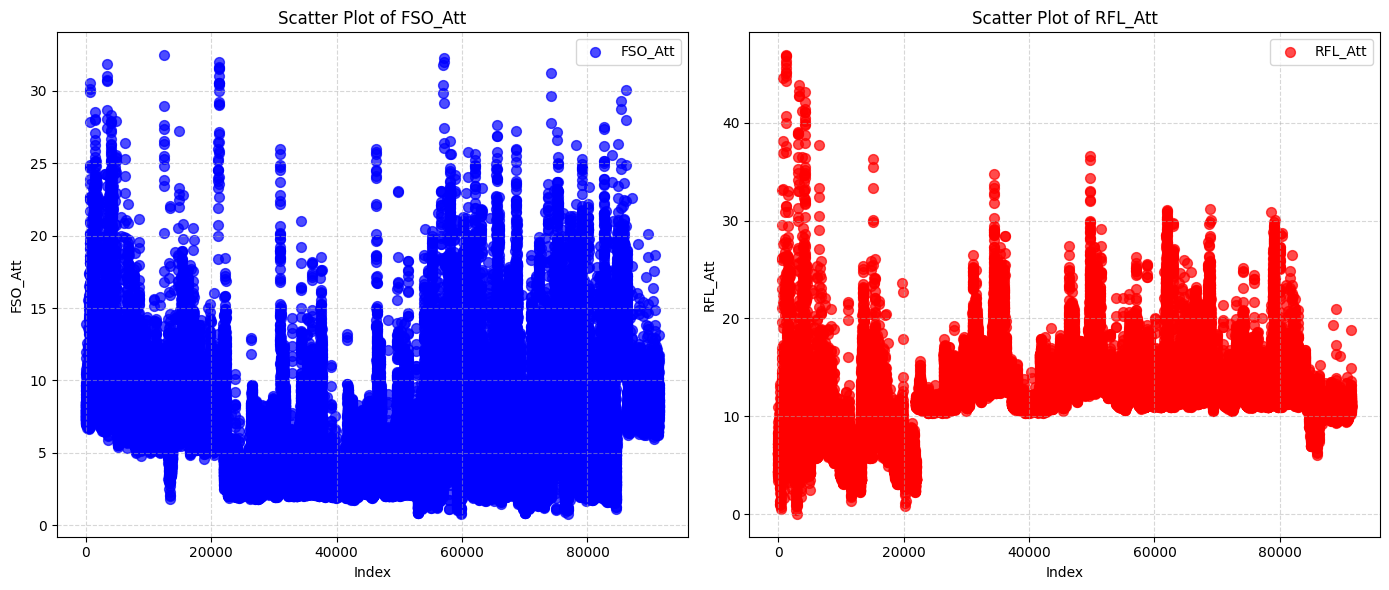

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Scatter plot for FSO_Att
axes[0].scatter(data.index, data["FSO_Att"], color="blue", alpha=0.7, s=50, label="FSO_Att")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("FSO_Att")
axes[0].set_title("Scatter Plot of FSO_Att")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Scatter plot for RFL_Att
axes[1].scatter(data.index, data["RFL_Att"], color="red", alpha=0.7, s=50, label="RFL_Att")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("RFL_Att")
axes[1].set_title("Scatter Plot of RFL_Att")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

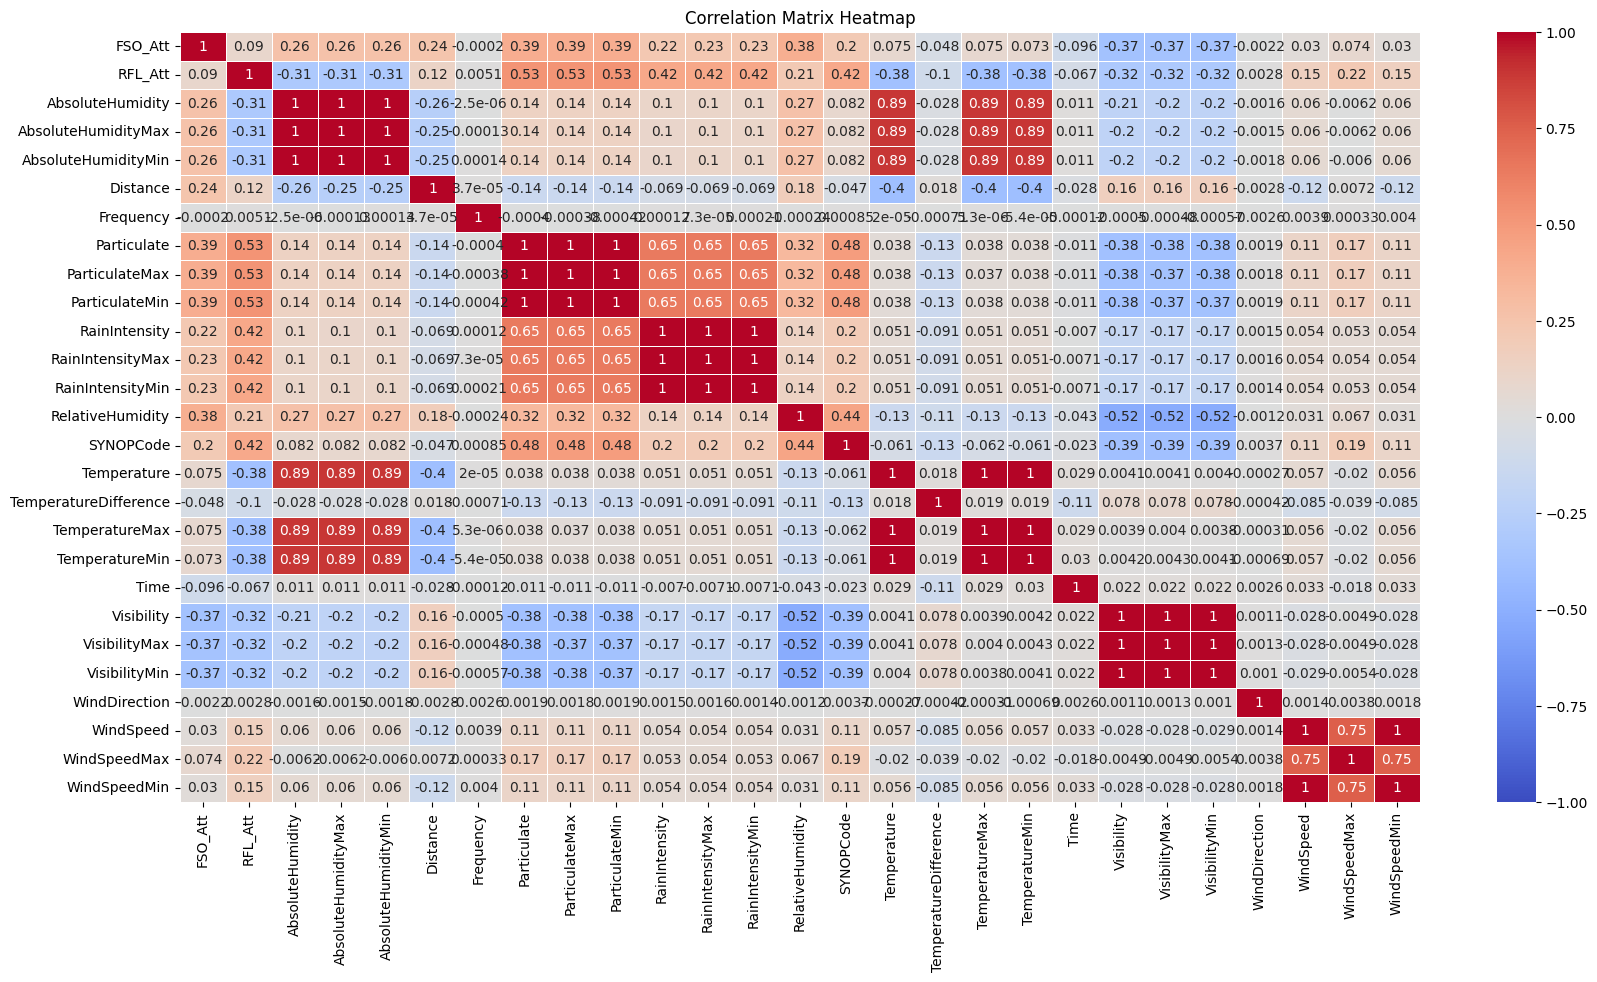

In [ ]:
# Now calculate the correlation matrix
corr_matrix = data.select_dtypes(include=np.number).corr()  # or data.select_dtypes(include=np.number).corr() for only numeric columns

# Create a heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# Display the plot
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
data.columns

Index(['FSO_Att', 'RFL_Att', 'AbsoluteHumidity', 'AbsoluteHumidityMax',
       'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate',
       'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax',
       'RainIntensityMin', 'RelativeHumidity', 'SYNOPCode', 'Temperature',
       'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Time',
       'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection',
       'WindSpeed', 'WindSpeedMax', 'WindSpeedMin'],
      dtype='object')

 Weak Dependence → A linear model might not capture the relationship well. Consider Non-Linear Approaches → Decision Trees

In [ ]:
dfs = {}
code_mapping = {
    '0': 'clear',
    '6': 'rain',
    '5': 'drizzle',
    '8': 'showers',
    '4': 'fog',
    '7': 'snow',
    '3': 'dust storm'
}

for code in data["SYNOPCode"].unique():
    code_name = code_mapping.get(str(code), str(code))  # Get the name or use the code itself as fallback
    dfs[f"{code_name}"] = data[data["SYNOPCode"] == code]


for name, dataframe in dfs.items():
    print(f"Size of {name}: {dataframe.shape}")

Size of clear: (56964, 27)
Size of rain: (25018, 27)
Size of showers: (1716, 27)
Size of drizzle: (6605, 27)
Size of dust storm: (191, 27)
Size of fog: (466, 27)
Size of snow: (419, 27)


In [ ]:
def evaluate_models(*dfs):
    results = []

    for df_index, df in enumerate(dfs):

        # Drop NaN values in target columns
        df = df.dropna(subset=['FSO_Att', 'RFL_Att'])

        # Features and Targets
        X = df.drop(columns=['FSO_Att', 'RFL_Att'])
        y_fso = df['FSO_Att']  # Target 1
        y_rfl = df['RFL_Att']  # Target 2

        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Train-test split
        X_train, X_test, y_fso_train, y_fso_test, y_rfl_train, y_rfl_test = train_test_split(
            X_scaled, y_fso, y_rfl, test_size=0.3, random_state=42
        )

        # Models to evaluate
        models = {
            "Linear Regression": LinearRegression(),
            "KNN": KNeighborsRegressor(),
            "SVM": SVR(),
            "Decision Tree": DecisionTreeRegressor()
        }

        # Train & Evaluate Models
        for model_name, model in models.items():
            # Train and predict for FSO_Att
            model.fit(X_train, y_fso_train)
            y_fso_pred = model.predict(X_test)
            fso_rmse = np.sqrt(mean_squared_error(y_fso_test, y_fso_pred))
            fso_r2 = r2_score(y_fso_test, y_fso_pred)

            # Train and predict for RFL_Att
            model.fit(X_train, y_rfl_train)
            y_rfl_pred = model.predict(X_test)
            rfl_rmse = np.sqrt(mean_squared_error(y_rfl_test, y_rfl_pred))
            rfl_r2 = r2_score(y_rfl_test, y_rfl_pred)

            # Store results
            results.append({
                "DataFrame": f"df_{df_index}",
                "Model": model_name,
                "FSO_RMSE": round(fso_rmse, 4),
                "FSO_R2": round(fso_r2, 4),
                "RFL_RMSE": round(rfl_rmse, 4),
                "RFL_R2": round(rfl_r2, 4),
            })

    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    print("\nFinal Results:")
    print(results_df)

    return results_df

In [ ]:
results_df = evaluate_models(dfs['clear'],dfs['drizzle'],dfs['dust storm'],dfs['fog'],dfs['rain'],dfs['showers'],dfs['snow'])


Final Results:
   DataFrame              Model  FSO_RMSE  FSO_R2  RFL_RMSE  RFL_R2
0       df_0  Linear Regression    3.0259  0.2692    2.0796  0.3448
1       df_0                KNN    1.5872  0.7989    0.7104  0.9235
2       df_0                SVM    1.9585  0.6939    0.9620  0.8598
3       df_0      Decision Tree    1.1858  0.8878    0.6287  0.9401
4       df_1  Linear Regression    2.1357  0.6520    1.7126  0.6614
5       df_1                KNN    1.5983  0.8051    1.0028  0.8839
6       df_1                SVM    1.7745  0.7597    1.1645  0.8435
7       df_1      Decision Tree    1.3827  0.8541    0.8781  0.9110
8       df_2  Linear Regression    4.6303  0.7358    0.9071  0.9143
9       df_2                KNN    4.3088  0.7712    0.4504  0.9789
10      df_2                SVM    6.4214  0.4919    0.7047  0.9483
11      df_2      Decision Tree    2.4420  0.9265    0.5726  0.9659
12      df_3  Linear Regression    1.4350  0.8603    0.8577  0.7677
13      df_3                KNN 

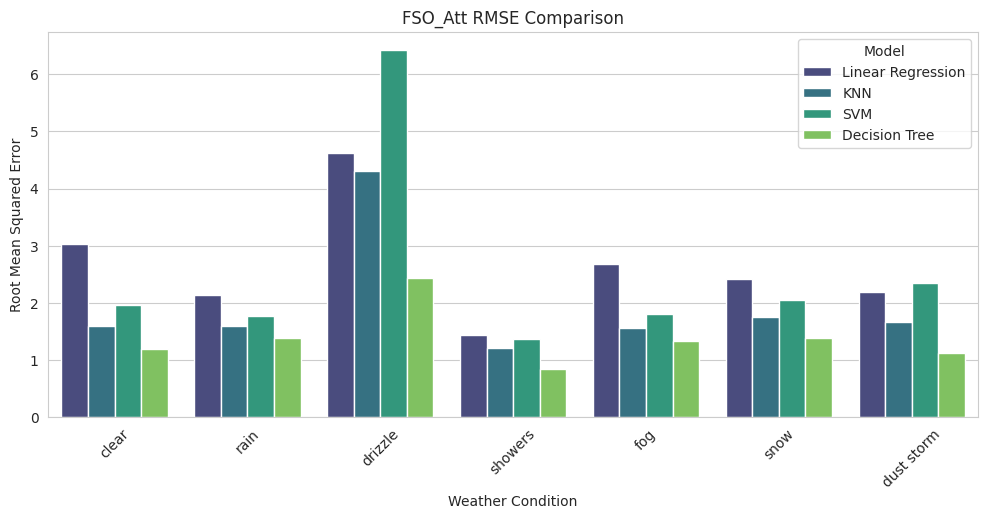

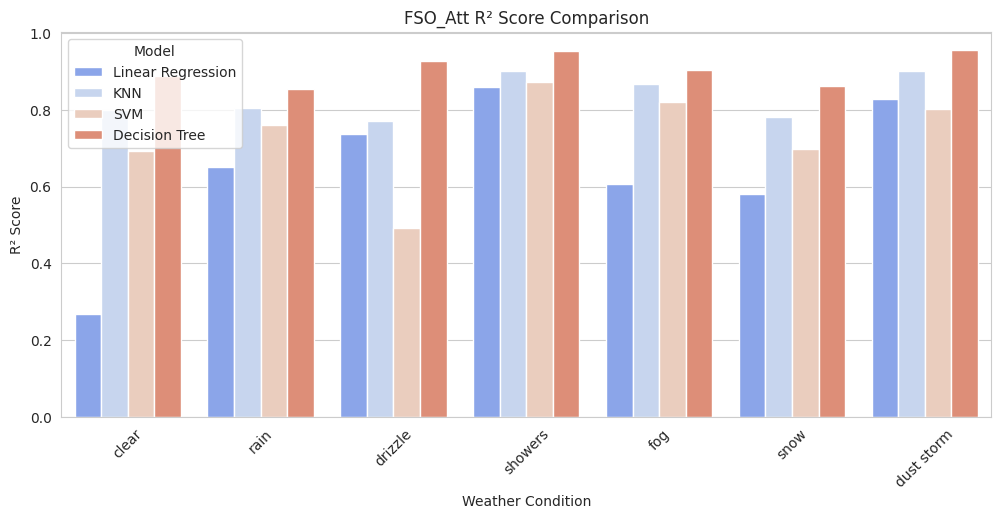

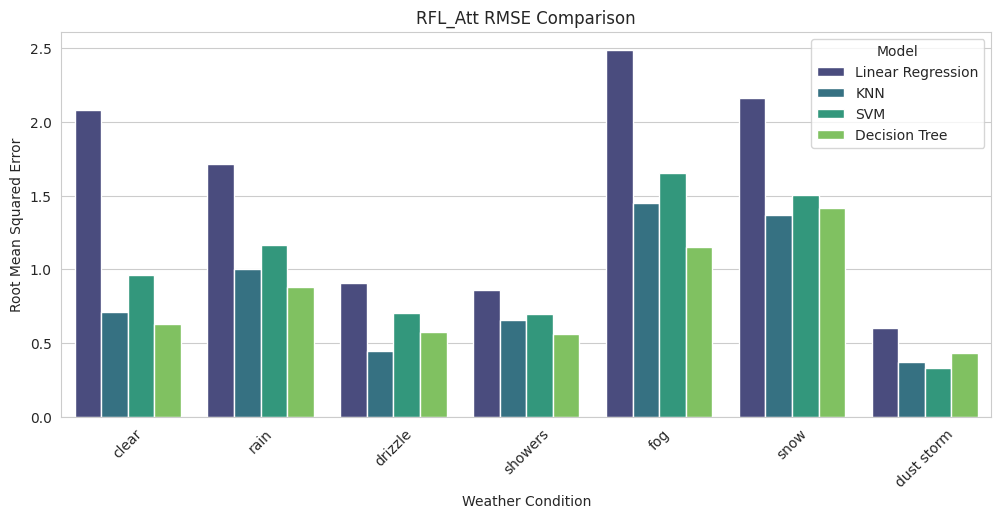

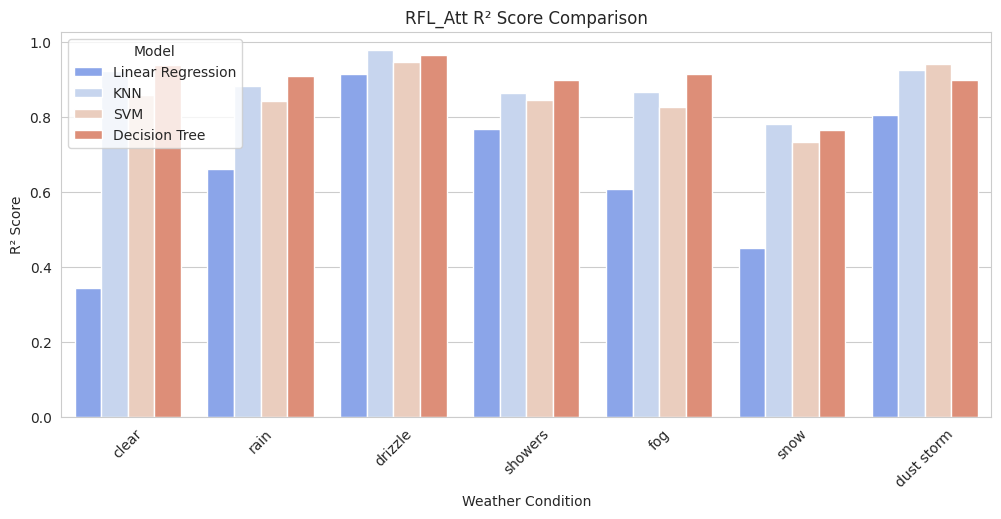

In [ ]:
def visualize_results(results_df):
    # Define the mapping of DataFrame names to weather names
    code_mapping = {
        'df_0': 'clear',
        'df_1': 'rain',
        'df_2': 'drizzle',
        'df_3': 'showers',
        'df_4': 'fog',
        'df_5': 'snow',
        'df_6': 'dust storm'
    }

    # Map the DataFrame names in the 'DataFrame' column to weather names
    results_df['Weather'] = results_df['DataFrame'].map(code_mapping)

    # Set Seaborn style
    sns.set_style("whitegrid")

    # Plot RMSE for FSO_Att
    plt.figure(figsize=(12, 5))
    sns.barplot(x="Weather", y="FSO_RMSE", hue="Model", data=results_df, palette="viridis")
    plt.title("FSO_Att RMSE Comparison")
    plt.ylabel("Root Mean Squared Error")
    plt.xlabel("Weather Condition")
    plt.legend(title="Model")
    plt.xticks(rotation=45)
    plt.show()

    # Plot R² Score for FSO_Att
    plt.figure(figsize=(12, 5))
    sns.barplot(x="Weather", y="FSO_R2", hue="Model", data=results_df, palette="coolwarm")
    plt.title("FSO_Att R² Score Comparison")
    plt.ylabel("R² Score")
    plt.xlabel("Weather Condition")
    plt.legend(title="Model")
    plt.xticks(rotation=45)
    plt.show()

    # Plot RMSE for RFL_Att
    plt.figure(figsize=(12, 5))
    sns.barplot(x="Weather", y="RFL_RMSE", hue="Model", data=results_df, palette="viridis")
    plt.title("RFL_Att RMSE Comparison")
    plt.ylabel("Root Mean Squared Error")
    plt.xlabel("Weather Condition")
    plt.legend(title="Model")
    plt.xticks(rotation=45)
    plt.show()

    # Plot R² Score for RFL_Att
    plt.figure(figsize=(12, 5))
    sns.barplot(x="Weather", y="RFL_R2", hue="Model", data=results_df, palette="coolwarm")
    plt.title("RFL_Att R² Score Comparison")
    plt.ylabel("R² Score")
    plt.xlabel("Weather Condition")
    plt.legend(title="Model")
    plt.xticks(rotation=45)
    plt.show()

# Call the function with the updated DataFrame
visualize_results(results_df)


In [ ]:
dfs.keys()

dict_keys(['clear', 'rain', 'showers', 'drizzle', 'dust storm', 'fog', 'snow'])

In [ ]:
def rank_feature_importance_oob(df, target_columns):
    """
    Rank the predictor variables based on their importance using a Random Forest with OOB estimation.
    The importance is ranked by removing the least important feature and evaluating performance.

    Args:
    - df: DataFrame, containing the dataset.
    - target_columns: list of str, the names of the target columns (e.g., ['FSO_Att', 'RFL_Att']).

    Returns:
    - results: DataFrame with ranked feature importance based on OOB R² and RMSE.
    """

    # Separate features and targets
    X = df.drop(columns=target_columns)
    y_fso = df[target_columns[0]]  # Target 1: FSO_Att
    y_rfl = df[target_columns[1]]  # Target 2: RFL_Att

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    feature_names = X.columns.tolist()

    # Initialize results table
    results = []

    # Set of features S (all features initially)
    S = feature_names.copy()

    # Loop until all features are removed
    while S:
        # Train-test split (80% train, 20% test)
        X_train, X_test, y_fso_train, y_fso_test, y_rfl_train, y_rfl_test = train_test_split(
            X_scaled[:, :len(S)], y_fso, y_rfl, test_size=0.2, random_state=42
        )

        # Train Random Forest with OOB for FSO
        rf_fso = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
        rf_fso.fit(X_train, y_fso_train)

        # Train Random Forest with OOB for RFL
        rf_rfl = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
        rf_rfl.fit(X_train, y_rfl_train)

        # Predictions for both targets
        y_fso_pred = rf_fso.predict(X_test)
        y_rfl_pred = rf_rfl.predict(X_test)

        # Compute RMSE and R² scores
        fso_rmse = np.sqrt(mean_squared_error(y_fso_test, y_fso_pred))
        fso_r2 = rf_fso.oob_score_  # OOB R² Score

        rfl_rmse = np.sqrt(mean_squared_error(y_rfl_test, y_rfl_pred))
        rfl_r2 = rf_rfl.oob_score_  # OOB R² Score

        # Store results for the current feature set
        results.append({
            "Removed Feature": None,  # Placeholder for removed feature in the first loop
            "FSO_RMSE": round(fso_rmse, 4),
            "FSO_OOB_R²": round(fso_r2, 4),
            "RFL_RMSE": round(rfl_rmse, 4),
            "RFL_OOB_R²": round(rfl_r2, 4),
        })

        # Compute feature importances
        fso_feature_importances = rf_fso.feature_importances_
        rfl_feature_importances = rf_rfl.feature_importances_

        # Calculate average feature importance
        avg_feature_importances = (fso_feature_importances + rfl_feature_importances) / 2

        # Identify the least important feature
        least_important_feature_index = np.argmin(avg_feature_importances)
        least_important_feature = S[least_important_feature_index]

        # Remove the least important feature from S
        S.remove(least_important_feature)

        # Store which feature was removed
        results[-1]["Removed Feature"] = least_important_feature

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    return results_df

target_columns = ['FSO_Att', 'RFL_Att']

In [ ]:
def plot_rmse_r2_separate(results_df):
    """
    Plots separate RMSE and R² score trends for FSO_Att and RFL_Att as features are removed.

    Args:
    - results_df: DataFrame containing the removed feature, RMSE, and R² scores.
    """
    x_labels = results_df["Removed Feature"].astype(str).tolist()   # Feature names on x-axis
    x_indices = range(len(x_labels))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    # Plot for FSO_Att
    ax1 = axes[0]
    ax1.plot(x_indices, results_df["FSO_RMSE"], label="FSO RMSE", color="blue", linestyle="dashed")
    ax1.set_xlabel("Predicting Features")
    ax1.set_ylabel("RMSE ", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_labels, rotation=45, ha="right")
    ax1_twin = ax1.twinx()
    ax1_twin.plot(x_indices, results_df["FSO_OOB_R²"], label="FSO R²", color="cyan", linestyle="dashed")
    ax1_twin.set_ylabel("R² Score", color="cyan")
    ax1_twin.tick_params(axis="y", labelcolor="cyan")
    ax1_twin.invert_xaxis()  # Reverse the R² axis to go right to left
    ax1.set_title("FSO_Att: RMSE and R² over Feature Removal")
    ax1.legend(loc="upper left")
    ax1_twin.legend(loc="upper right")
    ax1.grid(True, linestyle="--", alpha=0.6)
    change_idx = 6
    ax1.axvline(x=change_idx, color='green', linestyle='--', linewidth=2, label="Change Point")




    # Plot for RFL_Att
    ax2 = axes[1]
    ax2.plot(x_indices, results_df["RFL_RMSE"], label="RFL RMSE", color="red", linestyle="dashed")
    ax2.set_xlabel("Predicting Features")
    ax2.set_ylabel("RMSE", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(x_labels, rotation=45, ha="right")
    ax2_twin = ax2.twinx()
    ax2_twin.plot(x_indices, results_df["RFL_OOB_R²"], label="RFL R²", color="magenta", linestyle="dashed")
    ax2_twin.set_ylabel("R² Score ", color="magenta")
    ax2_twin.tick_params(axis="y", labelcolor="magenta")
    ax2_twin.invert_xaxis()  # Reverse the R² axis to go right to left
    ax2.set_title("RFL_Att: RMSE and R² over Feature Removal")
    ax2.legend(loc="upper left")
    ax2_twin.legend(loc="upper right")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.axvline(x=change_idx, color='green', linestyle='--', linewidth=2, label="Change Point")

    plt.tight_layout()
    plt.show()

df_Clear

In [ ]:
results_df_clear = rank_feature_importance_oob(dfs['clear'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_clear)



Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    0.8040      0.9438    0.3782      0.9751
1             Temperature    0.8040      0.9439    0.3792      0.9747
2   TemperatureDifference    0.8105      0.9429    0.3816      0.9767
3          TemperatureMax    0.8280      0.9409    0.3918      0.9759
4          TemperatureMin    0.8156      0.9425    0.3917      0.9760
5                    Time    0.8134      0.9437    0.3893      0.9760
6              Visibility    0.8062      0.9440    0.3813      0.9765
7           VisibilityMax    1.0131      0.9120    0.4384      0.9665
8           VisibilityMin    1.2021      0.8776    0.5020      0.9570
9           WindDirection    1.2043      0.8781    0.4973      0.9577
10              WindSpeed    1.2070      0.8789    0.4817      0.9583
11           WindSpeedMax    1.3587      0.8459    0.5305      0.9530
12           WindSpeedMin    1.374

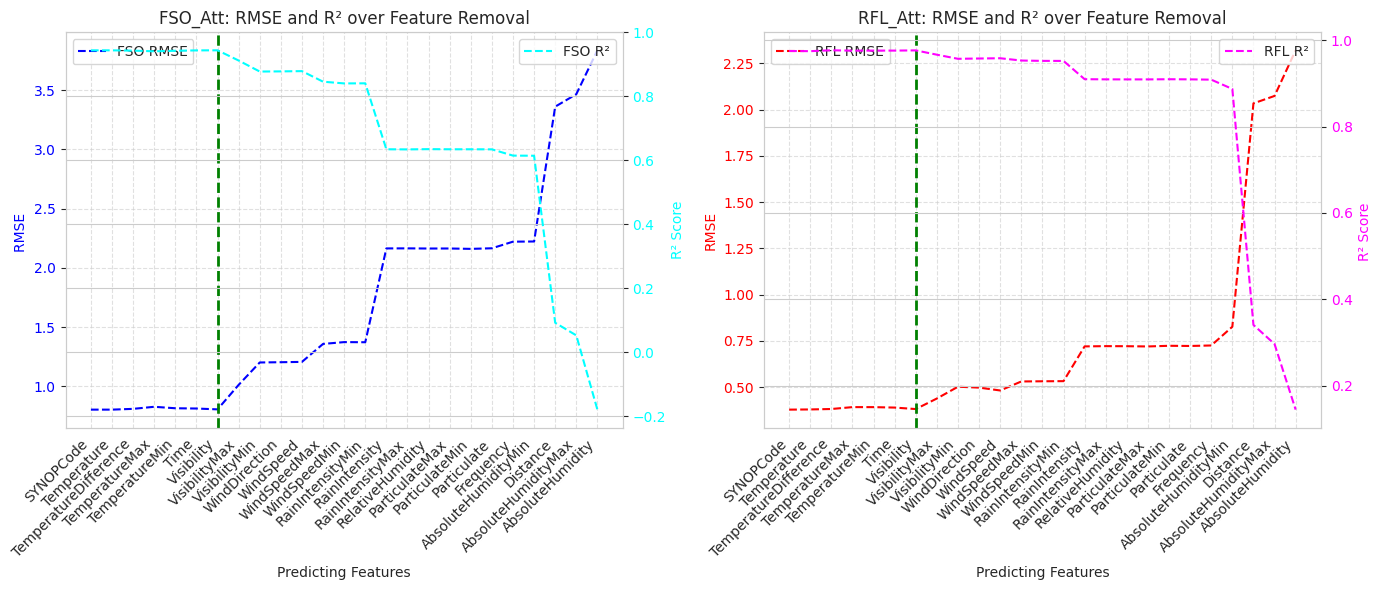

In [ ]:
plot_rmse_r2_separate(results_df_clear)

df_rain


In [ ]:
results_df_rain = rank_feature_importance_oob(dfs['rain'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_rain)



Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    0.8216      0.9594    0.7012      0.9651
1             Temperature    0.8230      0.9592    0.7011      0.9655
2   TemperatureDifference    0.8232      0.9584    0.7019      0.9658
3          TemperatureMax    0.8502      0.9566    0.6980      0.9663
4          TemperatureMin    0.8445      0.9576    0.6866      0.9672
5                    Time    0.8327      0.9579    0.6845      0.9674
6              Visibility    0.8334      0.9591    0.6797      0.9674
7           VisibilityMax    0.9570      0.9444    0.7525      0.9597
8           VisibilityMin    1.0716      0.9291    0.7902      0.9557
9           WindDirection    1.0673      0.9300    0.7888      0.9566
10              WindSpeed    1.0591      0.9311    0.7836      0.9568
11           WindSpeedMax    1.2604      0.9088    0.8880      0.9482
12           WindSpeedMin    1.326

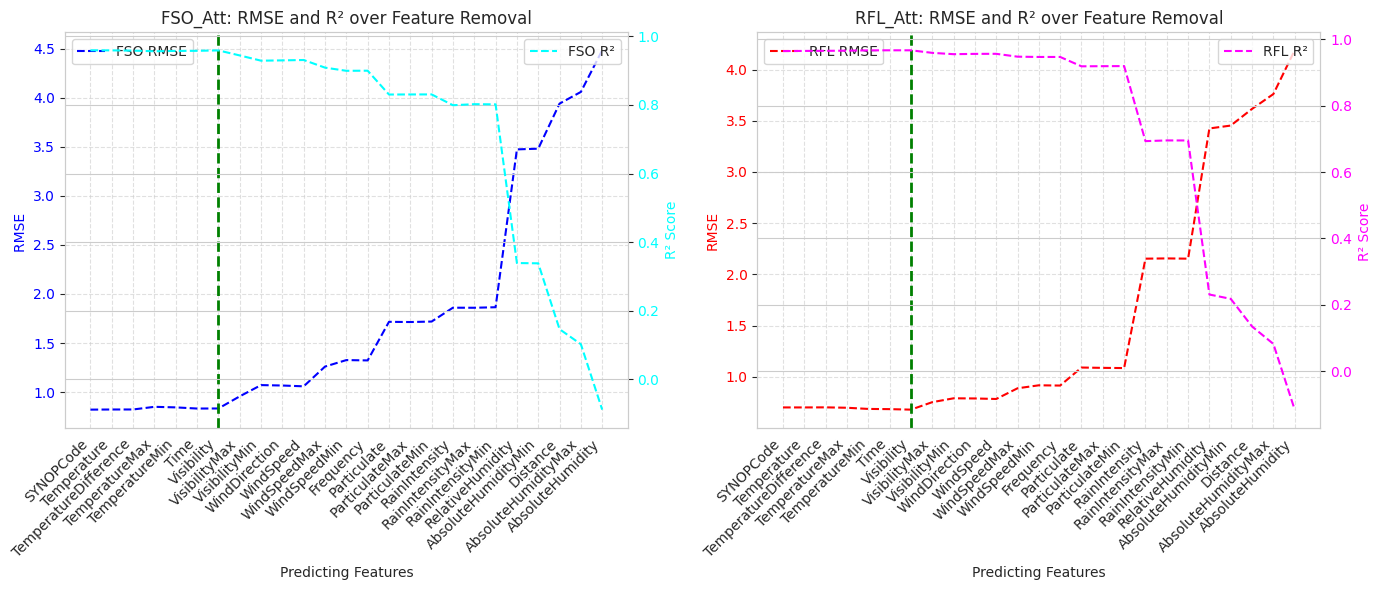

In [ ]:
plot_rmse_r2_separate(results_df_rain)

In [ ]:
results_df_drizzle = rank_feature_importance_oob(dfs['drizzle'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_drizzle)


Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    0.9738      0.9357    0.6201      0.9555
1             Temperature    0.9749      0.9354    0.6250      0.9550
2   TemperatureDifference    0.9718      0.9359    0.6248      0.9559
3          TemperatureMax    0.9502      0.9326    0.6277      0.9553
4          TemperatureMin    0.9282      0.9340    0.6209      0.9556
5                    Time    0.9262      0.9348    0.6209      0.9555
6              Visibility    0.9249      0.9368    0.6284      0.9558
7           VisibilityMax    1.0239      0.9140    0.6758      0.9523
8           VisibilityMin    1.0938      0.9005    0.6951      0.9498
9           WindDirection    1.0810      0.9022    0.7079      0.9506
10              WindSpeed    1.0806      0.9026    0.6634      0.9516
11           WindSpeedMax    1.2173      0.8766    0.7037      0.9438
12           WindSpeedMin    1.280

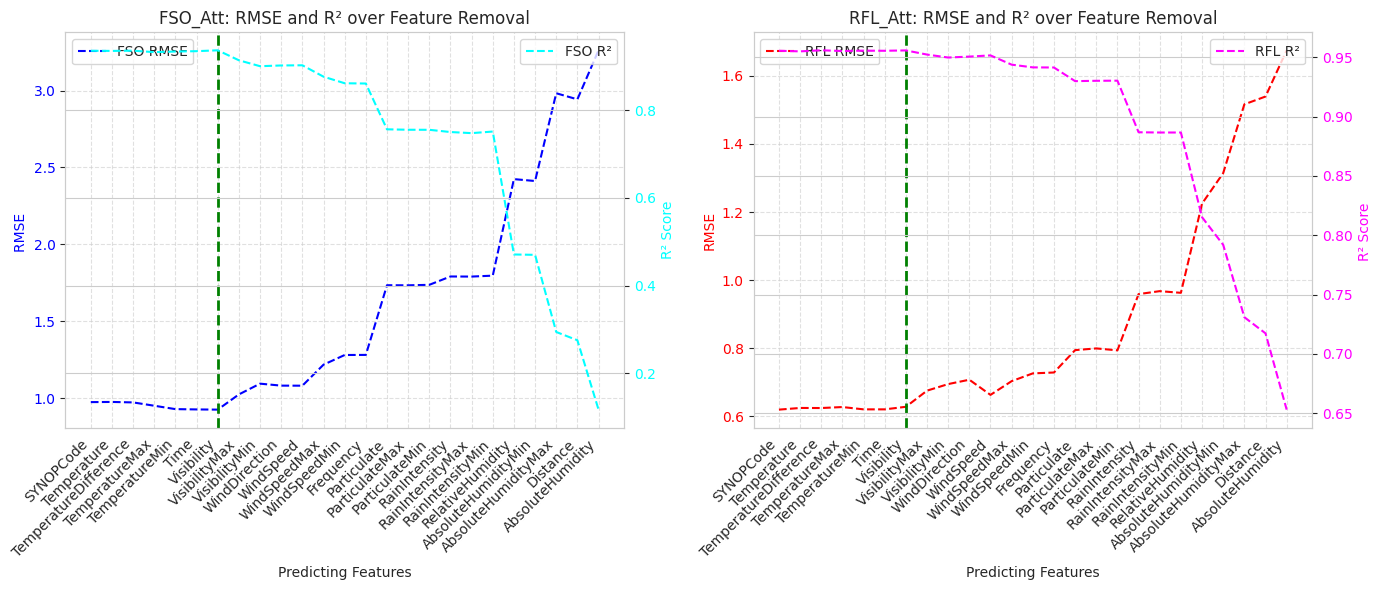

In [ ]:
plot_rmse_r2_separate(results_df_drizzle)

In [ ]:
results_df_showers = rank_feature_importance_oob(dfs['showers'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_showers)


Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    1.0020      0.9382    1.0135      0.8972
1             Temperature    0.9988      0.9401    1.0069      0.8975
2   TemperatureDifference    0.9806      0.9388    0.9954      0.8983
3          TemperatureMax    0.9762      0.9351    0.9921      0.9000
4          TemperatureMin    0.9919      0.9362    0.9722      0.9038
5                    Time    0.9615      0.9378    0.9871      0.9041
6              Visibility    0.9517      0.9385    0.9847      0.9042
7           VisibilityMax    0.9627      0.9179    1.0197      0.8955
8           VisibilityMin    1.0271      0.9117    1.0553      0.8927
9           WindDirection    1.0197      0.9125    1.0616      0.8952
10              WindSpeed    1.0170      0.9167    1.0399      0.8952
11           WindSpeedMax    1.1297      0.8978    1.0975      0.8848
12           WindSpeedMin    1.257

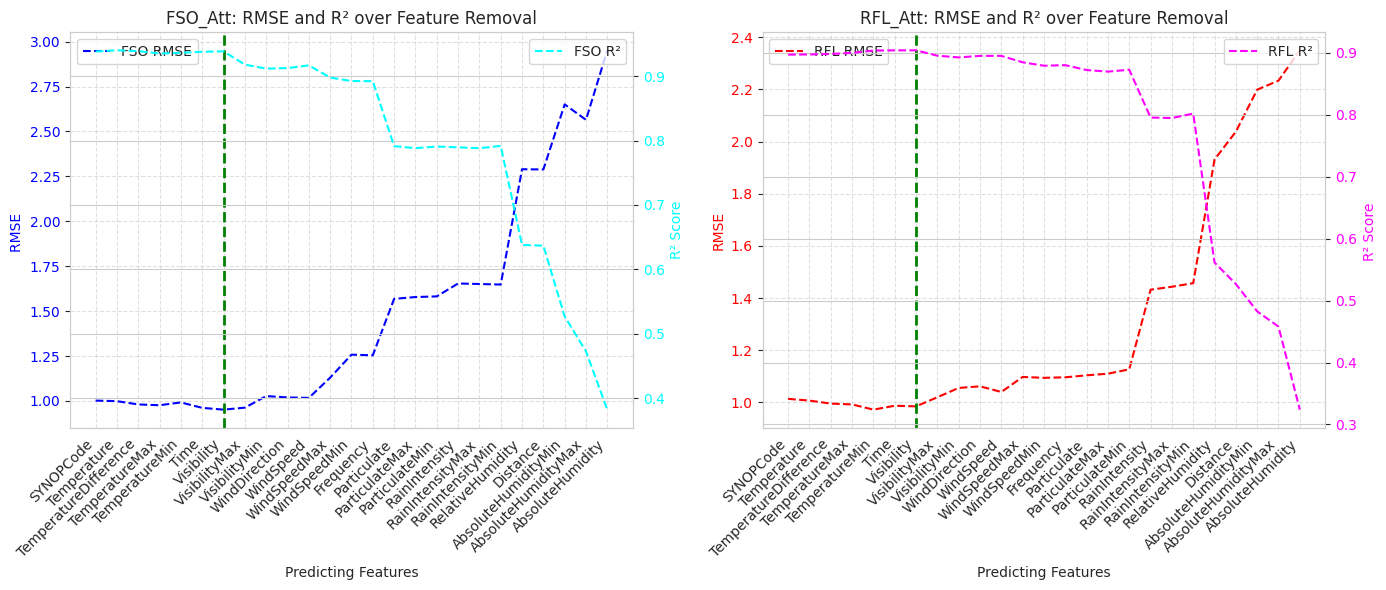

In [ ]:
plot_rmse_r2_separate(results_df_showers)

In [ ]:
results_df_fog = rank_feature_importance_oob(dfs['fog'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_fog)


Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    0.6943      0.9685    0.5273      0.9216
1             Temperature    0.6952      0.9680    0.5100      0.9225
2   TemperatureDifference    0.6365      0.9705    0.4887      0.9229
3          TemperatureMax    0.6489      0.9697    0.4778      0.9232
4          TemperatureMin    0.6339      0.9707    0.4907      0.9240
5                    Time    0.6255      0.9711    0.4721      0.9233
6              Visibility    0.6290      0.9707    0.4795      0.9239
7           VisibilityMax    0.8212      0.9586    0.5088      0.9210
8           VisibilityMin    0.9046      0.9465    0.5000      0.9207
9           WindDirection    0.9278      0.9458    0.4900      0.9184
10              WindSpeed    0.9028      0.9475    0.4844      0.9216
11           WindSpeedMax    0.9913      0.9405    0.4645      0.9194
12           WindSpeedMin    1.081

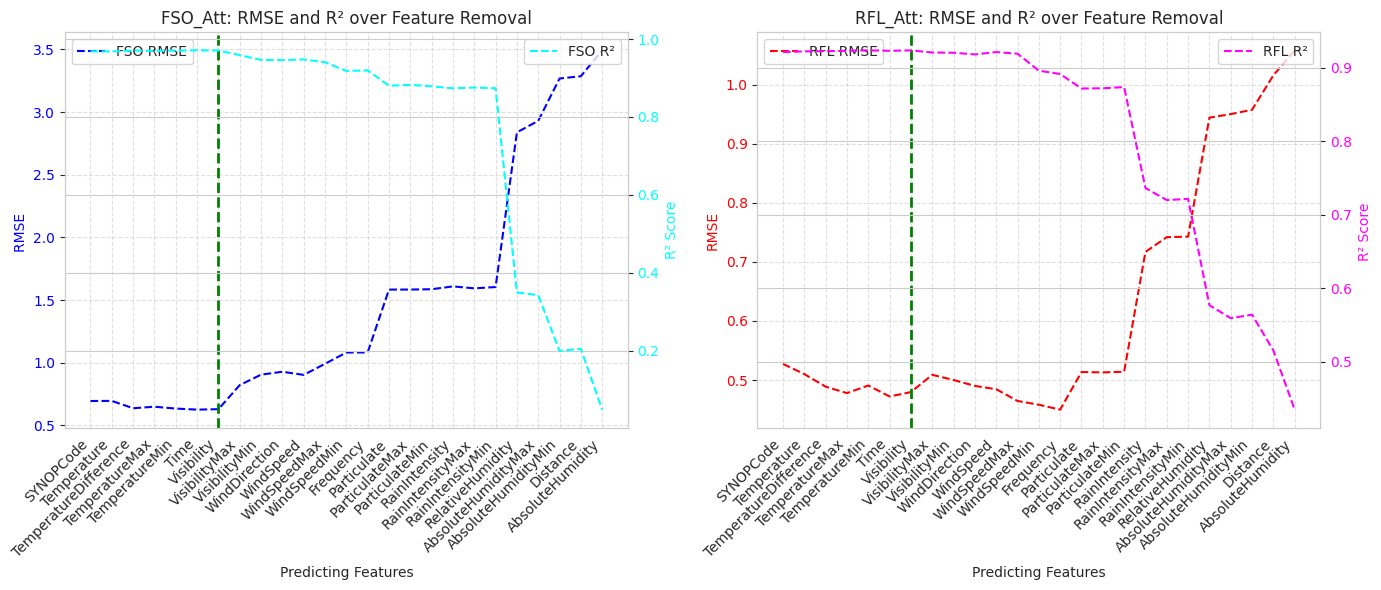

In [ ]:
plot_rmse_r2_separate(results_df_fog)

In [ ]:
results_df_snow = rank_feature_importance_oob(dfs['snow'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_snow)


Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0               SYNOPCode    0.9935      0.9394    0.2495      0.9496
1             Temperature    0.9893      0.9375    0.2520      0.9511
2   TemperatureDifference    0.9899      0.9290    0.2528      0.9493
3          TemperatureMax    1.1009      0.9278    0.2454      0.9500
4          TemperatureMin    1.0652      0.9301    0.2426      0.9524
5                    Time    1.0802      0.9287    0.2441      0.9504
6              Visibility    1.0874      0.9283    0.2539      0.9507
7           VisibilityMax    1.1691      0.9271    0.2586      0.9508
8           VisibilityMin    1.2333      0.9120    0.2510      0.9504
9           WindDirection    1.2523      0.9136    0.2546      0.9498
10              WindSpeed    1.2432      0.9152    0.2442      0.9511
11           WindSpeedMax    1.3164      0.8900    0.3194      0.9304
12           WindSpeedMin    1.517

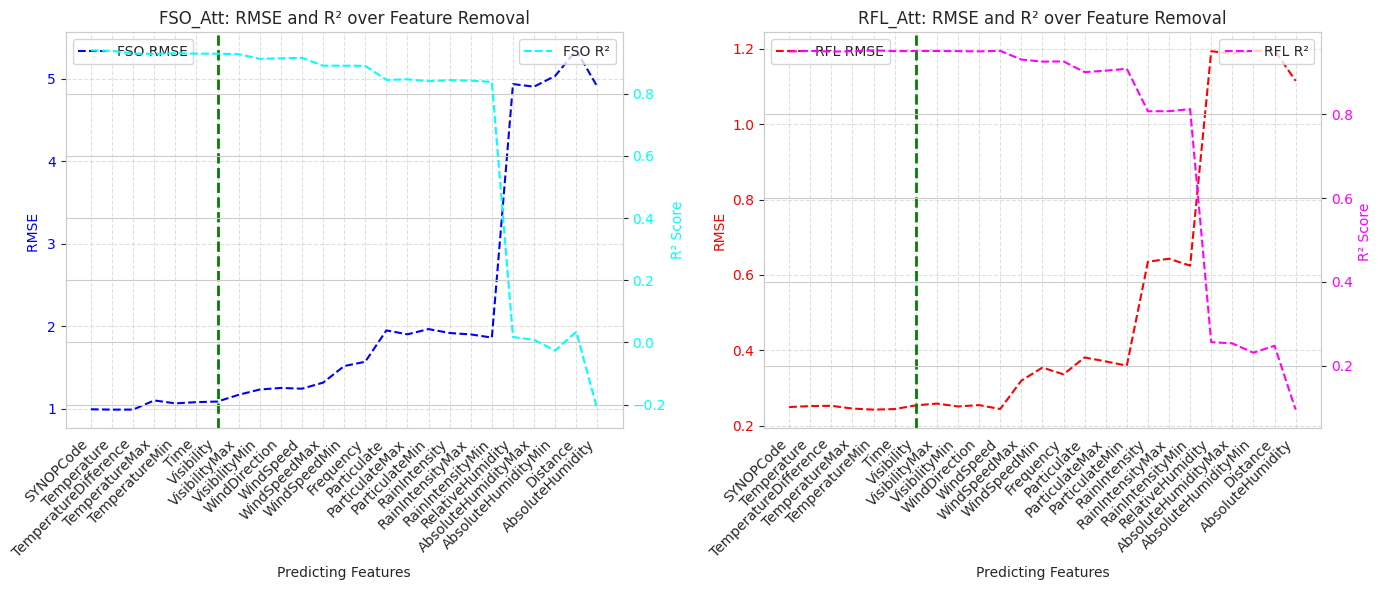

In [ ]:
plot_rmse_r2_separate(results_df_snow)

In [ ]:
results_df_dust_storms = rank_feature_importance_oob(dfs['dust storm'], target_columns)
print("\nFeature Ranking Based on RMSE and R² for both targets:")
print(results_df_dust_storms)


Feature Ranking Based on RMSE and R² for both targets:
          Removed Feature  FSO_RMSE  FSO_OOB_R²  RFL_RMSE  RFL_OOB_R²
0             Particulate    2.0805      0.9302    0.4014      0.9648
1          ParticulateMax    2.0965      0.9240    0.3942      0.9640
2          ParticulateMin    1.9436      0.9319    0.3998      0.9644
3           RainIntensity    1.9126      0.9289    0.4105      0.9613
4        RainIntensityMax    1.8669      0.9347    0.3843      0.9657
5        RainIntensityMin    1.7764      0.9368    0.3887      0.9636
6        RelativeHumidity    1.8628      0.9394    0.3894      0.9605
7               SYNOPCode    2.6014      0.9059    0.4154      0.9626
8             Temperature    3.2276      0.8907    0.4372      0.9623
9   TemperatureDifference    3.1225      0.8965    0.4403      0.9595
10         TemperatureMax    3.1234      0.8974    0.4316      0.9599
11         TemperatureMin    3.2284      0.8786    0.4683      0.9560
12                   Time    3.675

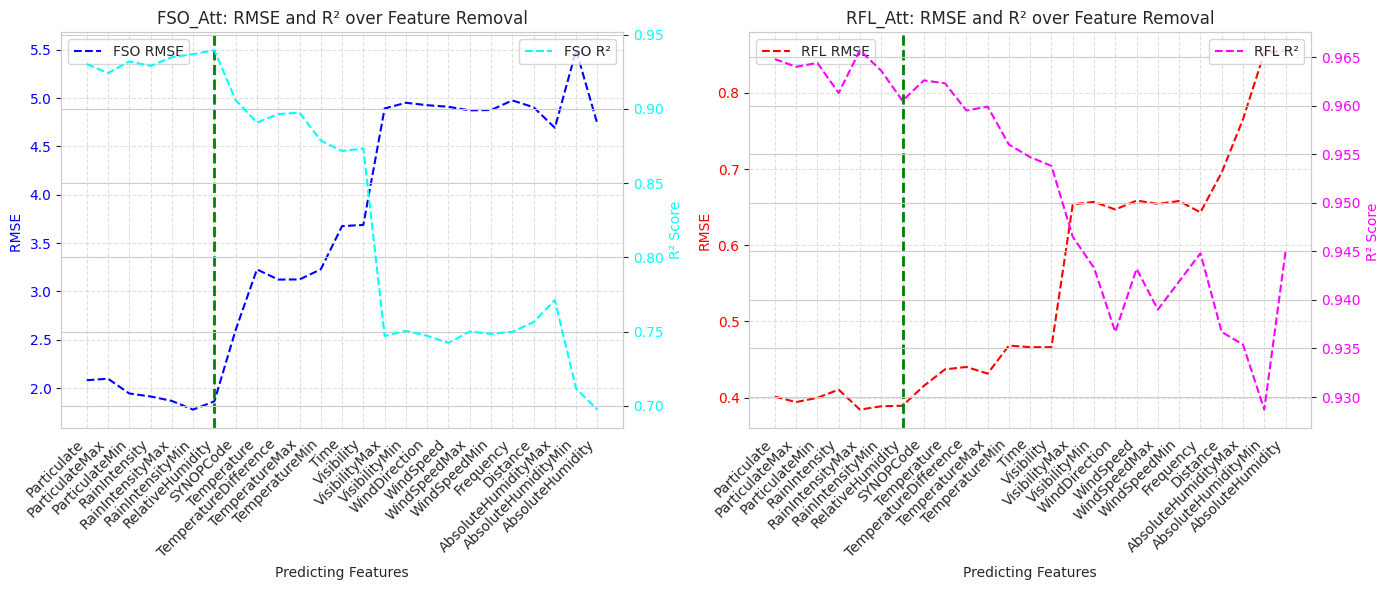

In [ ]:
plot_rmse_r2_separate(results_df_dust_storms)

In [ ]:
columns_to_remove = [
     'Temperature', 'TemperatureDifference', 'TemperatureMax',
    'TemperatureMin', 'Time', 'Visibility', 'VisibilityMin',
    'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'ParticulateMax',
    'ParticulateMin', 'RainIntensityMax', 'RainIntensityMin'
]

# Remove the columns
data_cleaned = data.drop(columns=columns_to_remove)

# Display the updated DataFrame info
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FSO_Att           91379 non-null  float64
 1   RFL_Att           91379 non-null  float64
 2   AbsoluteHumidity  91379 non-null  float64
 3   Distance          91379 non-null  float64
 4   Frequency         91379 non-null  int64  
 5   Particulate       91379 non-null  float64
 6   RainIntensity     91379 non-null  float64
 7   RelativeHumidity  91379 non-null  float64
 8   SYNOPCode         91379 non-null  int64  
 9   VisibilityMax     91379 non-null  float64
 10  WindDirection     91379 non-null  float64
 11  WindSpeed         91379 non-null  float64
 12  WindSpeedMax      91379 non-null  float64
 13  WindSpeedMin      91379 non-null  float64
dtypes: float64(12), int64(2)
memory usage: 9.8 MB


In [ ]:
X = data_cleaned.drop(columns=['FSO_Att', 'RFL_Att'])  # Features
y = data_cleaned['FSO_Att']  # You can choose to use 'RFL_Att' as the target too

# Split the data into training and testing sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print("Best Hyperparameters: ", grid_search.best_params_)

# Train the model with the best parameters
best_rf = grid_search.best_estimator_

# Predict on the test set
y_pred = best_rf.predict(X_test)

# Calculate the performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
